In [1]:
# !pip install pandas-datareader

In [1]:
import pandas as pd
import pandas_datareader as pdr
import pandas_datareader.data as web
from rols import RollingOLS

In [2]:
start = "12-1-1949"

# Get data

Source: [pandas-datareader](https://pandas-datareader.readthedocs.io/en/latest/remote_data.html#fred)

In [ ]:
factor_df = web.DataReader(['CPIAUCSL', 'CPILFESL'], 'fred', start=start, ).pct_change().dropna()
factors = factor_df.columns.tolist()
factor_df

/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_87230/2392094453.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  factor_df = web.DataReader(['CPIAUCSL', 'CPILFESL'], 'fred', start=start, ).pct_change().dropna()


,CPIAUCSL,CPILFESL
DATE,,
1957-02-01,0.004698,0.003509
1957-03-01,0.002158,0.003497
1957-04-01,0.002513,0.003484
1957-05-01,0.002506,0.000000
1957-06-01,0.003929,0.003472
...,...,...
2025-10-01,0.000000,0.000000
2025-11-01,0.002523,0.001892
2025-12-01,0.002978,0.002329


In [4]:
asset_df = web.DataReader('12_Industry_Portfolios', 'famafrench', start=start, )[1]
asset_df.index = asset_df.index.to_timestamp()
assets = asset_df.columns.tolist()
asset_df

/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_87230/3029172732.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  asset_df = web.DataReader('12_Industry_Portfolios', 'famafrench', start=start, )[1]
/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_87230/3029172732.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  asset_df = web.DataReader('12_Industry_Portfolios', 'famafrench', start=start, )[1]
/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_87230/3029172732.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 

,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Other
Date,,,,,,,,,,,,
1949-12-01,6.82,9.45,7.14,1.57,8.15,9.63,14.19,4.06,5.89,8.17,5.30,9.21
1950-01-01,4.60,4.76,3.53,1.76,0.71,10.18,2.15,3.98,2.94,2.16,1.67,5.78
1950-02-01,-0.69,2.95,2.72,-0.84,1.74,4.07,0.42,3.00,0.93,3.93,2.17,1.25
1950-03-01,-0.56,1.68,-1.30,3.42,-0.76,3.57,8.26,0.95,-1.60,-2.94,-0.17,-0.75
1950-04-01,1.82,10.33,6.15,4.09,6.41,9.09,17.12,0.21,2.76,5.62,0.93,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,-5.70,-6.90,0.45,1.13,-4.10,5.08,1.28,0.26,-5.77,6.08,-3.79,-4.26
2025-11-01,1.19,-1.29,-2.53,0.59,-2.97,-8.46,-1.32,5.36,-0.94,1.69,3.31,-0.89
2025-12-01,-4.45,-5.00,1.78,-2.93,-6.68,-1.82,3.64,-3.75,-2.94,-3.92,1.43,-0.76


In [5]:
control_df = pdr.get_data_famafrench("F-F_Research_Data_Factors", start=start, )[0].div(100.0).drop(columns=["RF"])
control_df.index = control_df.index.to_timestamp()
controls = control_df.columns.tolist()
# market_col = "Mkt-RF"
# controls = ["SMB", "HML"]
control_df

/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_87230/3967798396.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  control_df = pdr.get_data_famafrench("F-F_Research_Data_Factors", start=start, )[0].div(100.0).drop(columns=["RF"])
/var/folders/2k/kyptfbxj6l762gddhr91n4j80000gs/T/ipykernel_87230/3967798396.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  control_df = pdr.get_data_famafrench("F-F_Research_Data_Factors", start=start, )[0].div(100.0).drop(columns=["RF"])


,Mkt-RF,SMB,HML
Date,,,
1949-12-01,0.0514,0.0208,0.0173
1950-01-01,0.0170,0.0334,0.0015
1950-02-01,0.0148,0.0002,-0.0079
1950-03-01,0.0126,-0.0143,-0.0278
1950-04-01,0.0394,0.0200,0.0133
...,...,...,...
2025-10-01,0.0196,-0.0055,-0.0310
2025-11-01,-0.0013,0.0038,0.0376
2025-12-01,-0.0036,-0.0106,0.0242


In [6]:
df = pd.merge(factor_df, asset_df, left_index=True, right_index=True, how='left').ffill()
df = pd.merge(df, control_df, left_index=True, right_index=True, how='left').ffill()
df

,CPIAUCSL,CPILFESL,NoDur,Durbl,Manuf,Enrgy,Chems,BusEq,Telcm,Utils,Shops,Hlth,Money,Other,Mkt-RF,SMB,HML
DATE,,,,,,,,,,,,,,,,,
1957-02-01,0.004698,0.003509,-1.59,-2.59,-2.84,-3.44,-3.36,-2.54,-1.38,0.09,-1.12,0.14,-0.75,-4.07,-0.0207,-0.0075,-0.0066
1957-03-01,0.002158,0.003497,0.92,2.86,1.66,1.81,4.25,4.48,1.93,2.20,2.31,6.89,2.51,2.55,0.0213,0.0033,-0.0053
1957-04-01,0.002513,0.003484,2.08,2.89,2.10,5.45,1.29,5.14,4.18,2.25,1.52,4.60,4.26,2.54,0.0426,-0.0157,-0.0147
1957-05-01,0.002506,0.000000,0.73,1.48,1.47,7.24,3.88,4.32,1.00,1.91,2.40,4.52,4.02,1.28,0.0346,-0.0108,-0.0201
1957-06-01,0.003929,0.003472,-0.30,-0.43,-0.73,-4.10,1.37,1.68,-3.29,-4.77,0.66,4.12,-1.73,-0.03,-0.0075,0.0059,-0.0003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,0.000000,0.000000,-5.70,-6.90,0.45,1.13,-4.10,5.08,1.28,0.26,-5.77,6.08,-3.79,-4.26,0.0196,-0.0055,-0.0310
2025-11-01,0.002523,0.001892,1.19,-1.29,-2.53,0.59,-2.97,-8.46,-1.32,5.36,-0.94,1.69,3.31,-0.89,-0.0013,0.0038,0.0376
2025-12-01,0.002978,0.002329,-4.45,-5.00,1.78,-2.93,-6.68,-1.82,3.64,-3.75,-2.94,-3.92,1.43,-0.76,-0.0036,-0.0106,0.0242


# Roling Regression

In [7]:
ols = RollingOLS(window=12, expanding=False, lambda_=0.0)
ols.fit(factors=df[factors], controls=df[controls], orthogonalize_controls=True, orthogonalize_factors=True)
result = ols.transform(assets=df[assets])

In [8]:
factors

['CPIAUCSL', 'CPILFESL']

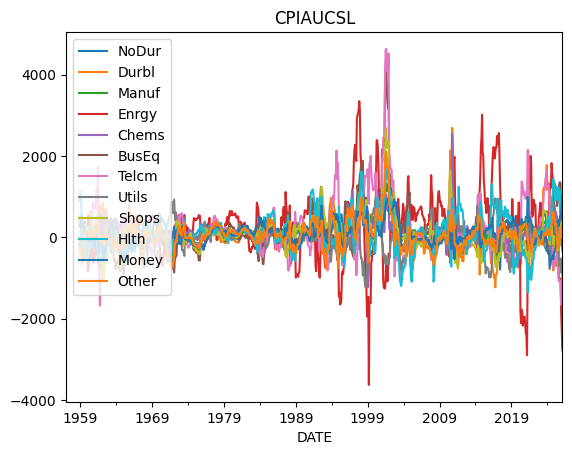

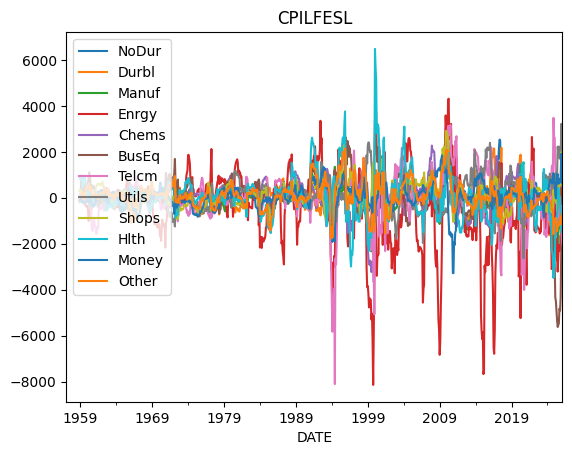

In [9]:
# result.get_beta(factors[0]).plot()
# result.get_beta("US Growth").plot()
import matplotlib.pyplot as plt
for f in factors:
    result.get_beta(f).plot(title=f)
    # plt.ylim(-2, 2)